In [22]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh, splu
from scipy.sparse import diags
import sys
sys.path.insert(0, '..')
from src.fatemarkers import FateMarkers
from src import utils

from meshplot import plot, subplot 
from matplotlib import pyplot as plt

import time 
from tqdm import tqdm
import os

from sklearn.decomposition import PCA

In [23]:
import jax 
import torch 

In [24]:
path = '../Data/20251001/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum_registered'],
    'day2': ['0_fused_zillum_registered'],
    'day2p5': ['0_fused_zillum_registered'],
    'day3': ['0_fused_zillum_registered'],
    'day3p5': ['0_fused_zillum_registered'],
    'day4': ['0_fused_zillum_registered'],
    'day4p5': ['0_fused_zillum_registered'],
    'day4p5-more': ['0_fused_zillum_registered'],
}



times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [25]:
annotation_names = {
    'lgr': '0.C02.percentile99_class',
    'chroma': '0.C03.percentile99_class',
    'cycd': '0.C04.percentile99_class',
    'muc': '1.C03.percentile99_class',
    'aldob': '1.C04.percentile99_class',
    'gluc': '2.C02.percentile99_class',
    'cyca': '2.C03.percentile99_class',
    'agr': '2.C04.percentile99_class',
    'sero': '3.C02.percentile99_class',
    'lyz': '3.C03.percentile99_class',
}

# load the fm vocabs 
res = np.load('../sim/vocab_fm.npz', allow_pickle=True)
vocab_fm = res['vocab']
sigma_fm = res['sigma']
fm_names_of_choice = res['fm_names_of_choice'].tolist()

print(fm_names_of_choice)

# load the hks vocabs 
res = np.load('../sim/vocab_new.npz', allow_pickle=True)
vocab_hks = res['vocab']
sigma_hks = res['sigma']
scaler_hks = res['scaler'].item() 
ts = res['ts']

['lgr', 'chroma', 'muc', 'aldob', 'agr', 'sero', 'lyz']


In [38]:
def load(mesh_path, save_path, ts, lmax=5, fate_encoding=True, hks_encoding=True, spectrum=False):
    m = FateMarkers()
    m.load_mesh_from_file(mesh_path)
    m.load_results(save_path)
    frac = m.compute_recon_quality()

    # compute hks 
    hks = m.compute_hks_for_new_times(ts, coeffs=False) 

    if hks_encoding: 
        hks_scaled = normalise_hks(hks)
        dist_hks = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab_hks[np.newaxis, :, :], axis=2)
        hks = np.exp(-dist_hks**2 / (2 * sigma_hks**2))

    hks_coeffs = m.modes[:, :int(lmax**2)].T @ (m.mass_matrix @ hks) / np.sqrt(m.mass_matrix.diagonal().sum())

    # store the area for normalisation 
    c = complexity(m) 

    # use encoding for fm 
    indices = [m.field_names.index(annotation_names[name]) for name in fm_names_of_choice] 
    selected_fields = m.fields[:, indices] 
    if fate_encoding:
        selected_fields = normalise_fm(selected_fields)
        selected_fields = np.linalg.norm(selected_fields[:, np.newaxis, :] - vocab_fm[np.newaxis, :, :], axis=2) 
        selected_fields = np.exp(-selected_fields**2 / (2 * sigma_fm**2))
    fm_coeffs = m.modes[:, :int(lmax**2)].T @ (m.mass_matrix @ selected_fields) / np.sqrt(m.mass_matrix.diagonal().sum())

    if spectrum: 
        fm_spectrum = m.compute_spectrum(fm_coeffs, lmax=lmax)
        hks_spectrum = m.compute_spectrum(hks_coeffs, lmax=lmax)
        return fm_spectrum, hks_spectrum, frac, c, m.area 
    else: 
        return fm_coeffs, hks_coeffs, frac, c, m.area 
    
def complexity(m, threshold=0.015): 
    for l in range(1, m.lmax+1): 
        err = m.compute_recon_quality(lmax=l)
        if err < threshold:
            return l
    return m.lmax

def normalise_fm(fm): 
    # Only compute upper quantile amongst non-zero values
    nonzero_mask = fm > 0
    upper_quantile = np.zeros((1, fm.shape[1]))
    for col in range(fm.shape[1]):
        nonzero_values = fm[nonzero_mask[:, col], col]
        if len(nonzero_values) > 0:
            upper_quantile[0, col] = np.percentile(nonzero_values, 75)
        else:
            upper_quantile[0, col] = 1  # avoid division by zero
    fm_normalised = fm / upper_quantile
    return (fm_normalised)

def normalise_hks(hks): 
    return scaler_hks.transform(hks / np.mean(hks, axis=0) - 1)

In [43]:
coeffs_hks = [] 
coeffs_fm = [] 
times = [] 
fracs = []
areas = [] 
ids = [] 
complexities = [] 

for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]
        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy")
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            mesh_path = f"{file_path}/meshes/nnorg_linked_multi_annotated_class/{label}.vtp"
            if os.path.exists(save_path + '_coeffs.npz'):
                try: 
                    c1, c2, frac, c, A  = load(mesh_path, save_path, ts, spectrum=False, fate_encoding=True, lmax=5)
                    coeffs_fm.append(c1)
                    coeffs_hks.append(c2)
                    times.append(timepoint[3:6])
                    fracs.append(frac)
                    areas.append(A)
                    complexities.append(c)
                    ids.append(f"{timepoint}_{well_name}_{label}") 
                except:
                    print(f"Error loading {mesh_path}")
                    continue

 42%|████▏     | 50/120 [00:07<00:08,  8.27it/s]

Error loading ../Data/20251001/day4p5-more/r0.zarr/C/03/0_fused_zillum_registered//meshes/nnorg_linked_multi_annotated_class/20.vtp


100%|██████████| 60/60 [00:08<00:00,  7.09it/s]


In [27]:
# make a pandas table with frac, areas, complexities and ids 

import pandas as pd 
data = {
    'id': ids,
    'time': times,
    'fraction_recon': fracs,
    'area': areas,
    'complexity': complexities
}
df = pd.DataFrame(data)
df.to_csv(f'{path}/organoids_metadata.csv', index=False)

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class LinearModel(nn.Module):
    """Simple linear regression model."""
    
    def __init__(self, input_dim, output_dim=1):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


def train_model(model, train_loader, criterion, optimizer, epochs=100):
    """Train the model."""
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            # Forward pass
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    return losses

def train_with_validation(model, train_loader, test_loader, criterion, optimizer, verbose=False, epochs=100):
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)
                test_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader))
        test_losses.append(test_loss / len(test_loader))
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')
    
    return train_losses, test_losses


def evaluate_model(model, test_loader, criterion):
    """Evaluate the model."""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            total_loss += loss.item()
    
    avg_loss = total_loss / len(test_loader)
    return avg_loss

In [45]:
threshold = np.percentile(fracs, 95)
recon_mask = (np.array(fracs) < threshold) & (np.all(np.array(coeffs_fm) == 0, axis=(1, 2)) == False)
filtered_times = np.array(times)[recon_mask]
filtered_hks = np.array(coeffs_hks)[recon_mask]
filtered_areas = np.array(areas)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]
coeffs_fm_filtered = np.array(coeffs_fm)[recon_mask]

In [46]:
print(coeffs_fm_filtered.shape, filtered_hks.shape)

(2667, 25, 5) (2667, 25, 8)


In [150]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def coeff_rescaling(coeffs): 
    upper_quantile = np.percentile(coeffs[:, 0, :], 75, axis=0)
    upper_quantile[upper_quantile == 0] = 1  # avoid division by zero
    coeffs /= upper_quantile[np.newaxis, np.newaxis, :]
    return np.log(coeffs + 1e-5)

def preprocess(coeffs, indices):  
    coeffs_rescaled = coeff_rescaling(coeffs)
    coeffs_reshaped = np.array(coeffs_rescaled[:, :, indices]).transpose(0, 2, 1).reshape(len(filtered_times), -1)
    coeffs_reshaped = scaler.fit_transform(coeffs_reshaped)
    return coeffs_reshaped


def coeffs_to_spectrums(coeffs): 
    n_samples = coeffs.shape[0]
    n_modes = coeffs.shape[1]
    lmax = int(np.sqrt(n_modes))
    spectrums = np.zeros((n_samples, lmax, coeffs.shape[2]))
    for l in range(lmax):
        start = l**2
        end = (l+1)**2
        spectrums[:, l] = np.sum(coeffs[:, start:end]**2, axis=1)
    return spectrums

def compute_cross_terms(coeffs):
    cross_terms = [] 
    for i in range(coeffs.shape[2]):
        for j in range(i+1, coeffs.shape[2]):
            cross_term = np.sum(coeffs[:, 1:, i] * coeffs[:, 1:, j], axis=1)/np.sqrt(np.sum(coeffs[:, :, i]**2, axis=1) * np.sum(coeffs[:, :, j]**2, axis=1) + 1e-8)
            cross_terms.append(cross_term)
    return np.array(cross_terms).T  # shape (n_samples, n_cross_terms)1

In [151]:
from sklearn.model_selection import KFold

def data_handling(X_final, Y_final, n_splits=5): 
    """Create K-Fold cross-validation splits."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Convert to torch tensors
    X_tensor = torch.from_numpy(X_final).float()
    Y_tensor = torch.from_numpy(Y_final).float()
    
    # Create list of train/test loaders for each fold
    fold_loaders = []
    for train_idx, test_idx in kfold.split(X_final):
        train_dataset = TensorDataset(X_tensor[train_idx], Y_tensor[train_idx])
        test_dataset = TensorDataset(X_tensor[test_idx], Y_tensor[test_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        fold_loaders.append((train_loader, test_loader))
    
    return fold_loaders

def linear_fit_exact(X_final, Y_final):
    """Compute exact linear regression solution using normal equations."""
    X_with_bias = np.column_stack([X_final, np.ones(X_final.shape[0])])
    weights = np.linalg.lstsq(X_with_bias, Y_final, rcond=None)[0]
    Y_pred = X_with_bias @ weights
    mse = np.mean((Y_final - Y_pred) ** 2)
    return mse, weights 

def MLP_fit(fold_loaders, X_final, Y_final): 
    """Train MLP with K-fold cross-validation."""
    all_train_losses = []
    all_test_losses = []
    
    for fold_idx, (train_loader, test_loader) in enumerate(fold_loaders):
        model = nn.Sequential(
            nn.Linear(X_final.shape[1], 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16), 
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, Y_final.shape[1])
        )
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

        train_losses, test_losses = train_with_validation(model, train_loader, test_loader, criterion, optimizer, verbose=False, epochs=100)
        all_train_losses.append(train_losses[-1])
        all_test_losses.append(test_losses[-1])
    
    # Return average losses across folds and the last trained model
    return all_train_losses, all_test_losses, model

In [152]:
fm_spectrums = coeffs_to_spectrums(coeffs_fm_filtered)
cross_terms = compute_cross_terms(coeffs_fm_filtered)

hks_spectrums = coeffs_to_spectrums(filtered_hks)

spectrums_fm_reshaped = preprocess(fm_spectrums, [0, 1, 2, 3, 4])
spectrums_hks_reshaped = preprocess(hks_spectrums, [-1])
sample_filter = np.any(np.abs(spectrums_hks_reshaped) > 3, axis=1) | np.any(spectrums_fm_reshaped > 4, axis=1)
X = np.concatenate([spectrums_fm_reshaped, cross_terms], axis=1)

In [153]:
Y_final = spectrums_hks_reshaped[~sample_filter]
X_inter = X[~sample_filter]

X_inter = scaler.fit_transform(X_inter)

X1 = X_inter[:, :spectrums_fm_reshaped.shape[1]]
X2 = X_inter[:, spectrums_fm_reshaped.shape[1]:]
X3 = np.copy(X_inter)

linear_loss = [] 
mlp_loss = []
for X_inter in [X1, X2, X3]:
    print(X_inter.shape) 
    pca = PCA(n_components=X_inter.shape[1]) 
    n_componets = X_inter.shape[1]
    X_final = pca.fit_transform(X_inter)[:, :n_componets]

    mlp_loss_temp = []
    for j in range(1): 
        fold_loaders = data_handling(X_final, Y_final)
        train_losses, test_losses, mlp_model = MLP_fit(fold_loaders, X_final, Y_final)
        mlp_loss_temp.append([train_losses, test_losses]) 
    linear_loss_temp, w = linear_fit_exact(X_final, Y_final)
    linear_loss.append(linear_loss_temp)
    mlp_loss.append((mlp_loss_temp))
    

(2667, 25)
(2667, 10)
(2667, 35)


[0.27927674734152597, 0.49930084215015863, 0.259661610430897]


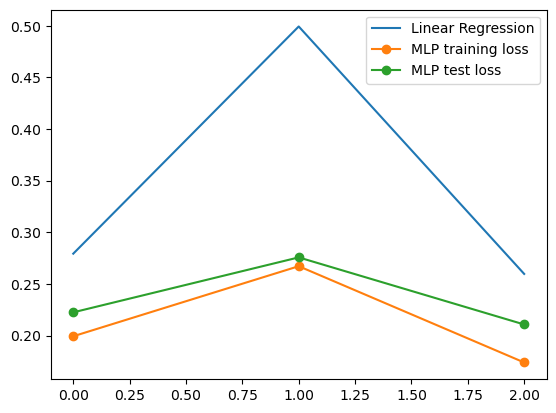

In [154]:
plt.plot(linear_loss, label='Linear Regression')
print(linear_loss)
plt.plot(np.mean(np.array(mlp_loss)[:,:,0,:], axis=(1, -1)), 'o-', label='MLP training loss')
plt.plot(np.mean(np.array(mlp_loss)[:,:,1,:], axis=(1, -1)), 'o-', label='MLP test loss')
plt.legend() 
plt.show() 

### Linear model with each fate marker predicting each HKS component

In [17]:
from itertools import combinations

mlp_loss = [] 
linear_loss_exact = [] 
fm_names_of_choice = ['endocrine', 'none', 'aldob', 'stem', 'exocrine']

# important_fms = [0, 2, 3, 5, 6]  # Indices of important fate markers
important_fms = [0, 1, 2, 3, 4]  # Indices of important fate markers

fate_combinations = [[i] for i in important_fms] + [list(combo) for combo in combinations(important_fms, 2)] + [list(combo) for combo in combinations(important_fms, 3)] + [list(combo) for combo in combinations(important_fms, 4)] + [important_fms]

for i in range(len(fate_combinations)):
    print(f"Preprocessing FM: {np.array(fm_names_of_choice)[fate_combinations[i]]}")
    coeffs_fm_reshaped = preprocess(coeffs_fm_filtered, fate_combinations[i])
    coeffs_hks_reshaped = preprocess(filtered_hks, [-1])
    sample_filter = np.any(np.abs(coeffs_hks_reshaped) > 3, axis=1) | np.any(coeffs_fm_reshaped > 4, axis=1)

    Y_final = coeffs_hks_reshaped[~sample_filter]
    X_inter = coeffs_fm_reshaped[~sample_filter]
    pca = PCA(n_components=X_inter.shape[1]) 
    n_componets = 10 if X_inter.shape[1] >= 10 else X_inter.shape[1]
    X_final = pca.fit_transform(X_inter)[:, :n_componets]

    test_loader, train_loader = data_handling(X_final, Y_final)

    linear_loss_temp = [] 
    mlp_loss_temp = []
    for j in range(10): # repeat 10 times to average out randomness
        train_losses, test_losses, mlp_model = MLP_fit(test_loader, train_loader, X_final, Y_final)
        mlp_loss_temp.append(train_losses[-1])
    mlp_loss.append((mlp_loss_temp))
    linear_loss_temp, w = linear_fit_exact(X_final, Y_final)
    linear_loss_exact.append(linear_loss_temp)
    

Preprocessing FM: ['endocrine']
Preprocessing FM: ['none']
Preprocessing FM: ['aldob']
Preprocessing FM: ['stem']
Preprocessing FM: ['exocrine']
Preprocessing FM: ['endocrine' 'none']
Preprocessing FM: ['endocrine' 'aldob']
Preprocessing FM: ['endocrine' 'stem']
Preprocessing FM: ['endocrine' 'exocrine']
Preprocessing FM: ['none' 'aldob']
Preprocessing FM: ['none' 'stem']
Preprocessing FM: ['none' 'exocrine']
Preprocessing FM: ['aldob' 'stem']
Preprocessing FM: ['aldob' 'exocrine']
Preprocessing FM: ['stem' 'exocrine']
Preprocessing FM: ['endocrine' 'none' 'aldob']
Preprocessing FM: ['endocrine' 'none' 'stem']
Preprocessing FM: ['endocrine' 'none' 'exocrine']
Preprocessing FM: ['endocrine' 'aldob' 'stem']
Preprocessing FM: ['endocrine' 'aldob' 'exocrine']
Preprocessing FM: ['endocrine' 'stem' 'exocrine']
Preprocessing FM: ['none' 'aldob' 'stem']
Preprocessing FM: ['none' 'aldob' 'exocrine']
Preprocessing FM: ['none' 'stem' 'exocrine']
Preprocessing FM: ['aldob' 'stem' 'exocrine']
Prepr

(36, 5)


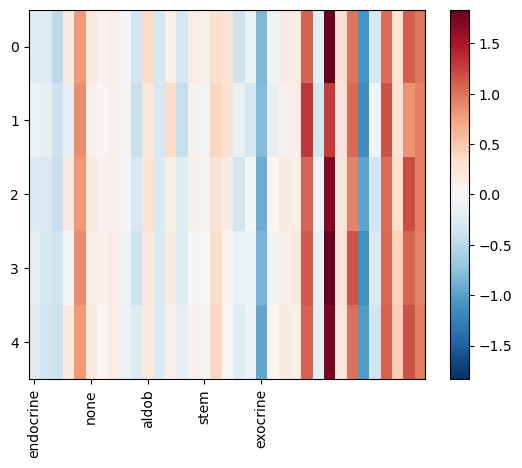

In [99]:
print(w.shape) 

weights = (pca.components_[:n_componets, :].T @ w[:-1, :]) 

# plot the weights of the full linear model with all fate markers
plt.imshow(weights.T, aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(weights)), vmax=np.max(np.abs(weights)))
plt.xticks(ticks=np.arange(0, len(important_fms)*5, 5), labels=np.array(fm_names_of_choice)[important_fms], rotation=90)
plt.colorbar() 
plt.show() 

In [33]:
mlp_loss_m = np.mean(np.array(mlp_loss), axis=1)
mlp_loss_std = np.std(np.array(mlp_loss), axis=1)

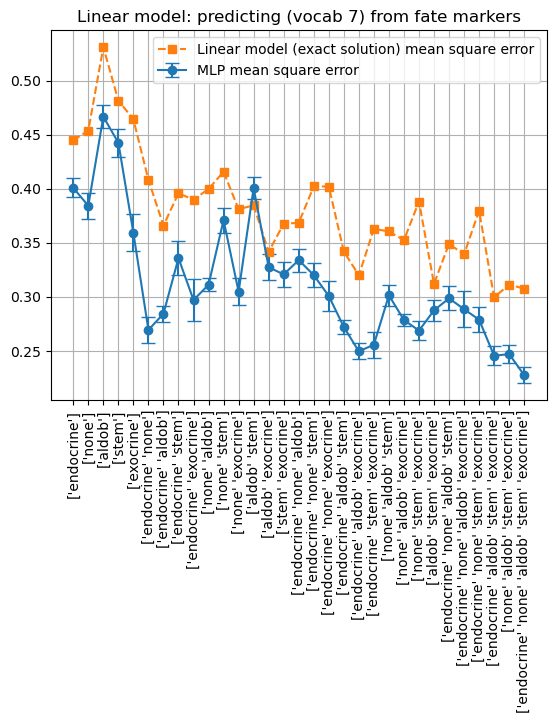

In [20]:
plt.errorbar(np.arange(len(fate_combinations)), mlp_loss_m, yerr=mlp_loss_std, fmt='o-', capsize=5, label='MLP mean square error')
plt.plot(np.arange(len(fate_combinations)), linear_loss_exact, 's--', label='Linear model (exact solution) mean square error')
plt.xticks(ticks=np.arange(len(fate_combinations)), labels=[np.array(fm_names_of_choice)[fc] for fc in fate_combinations], rotation=90)
plt.title('Linear model: predicting (vocab 7) from fate markers')
plt.grid()
plt.legend()
plt.show()

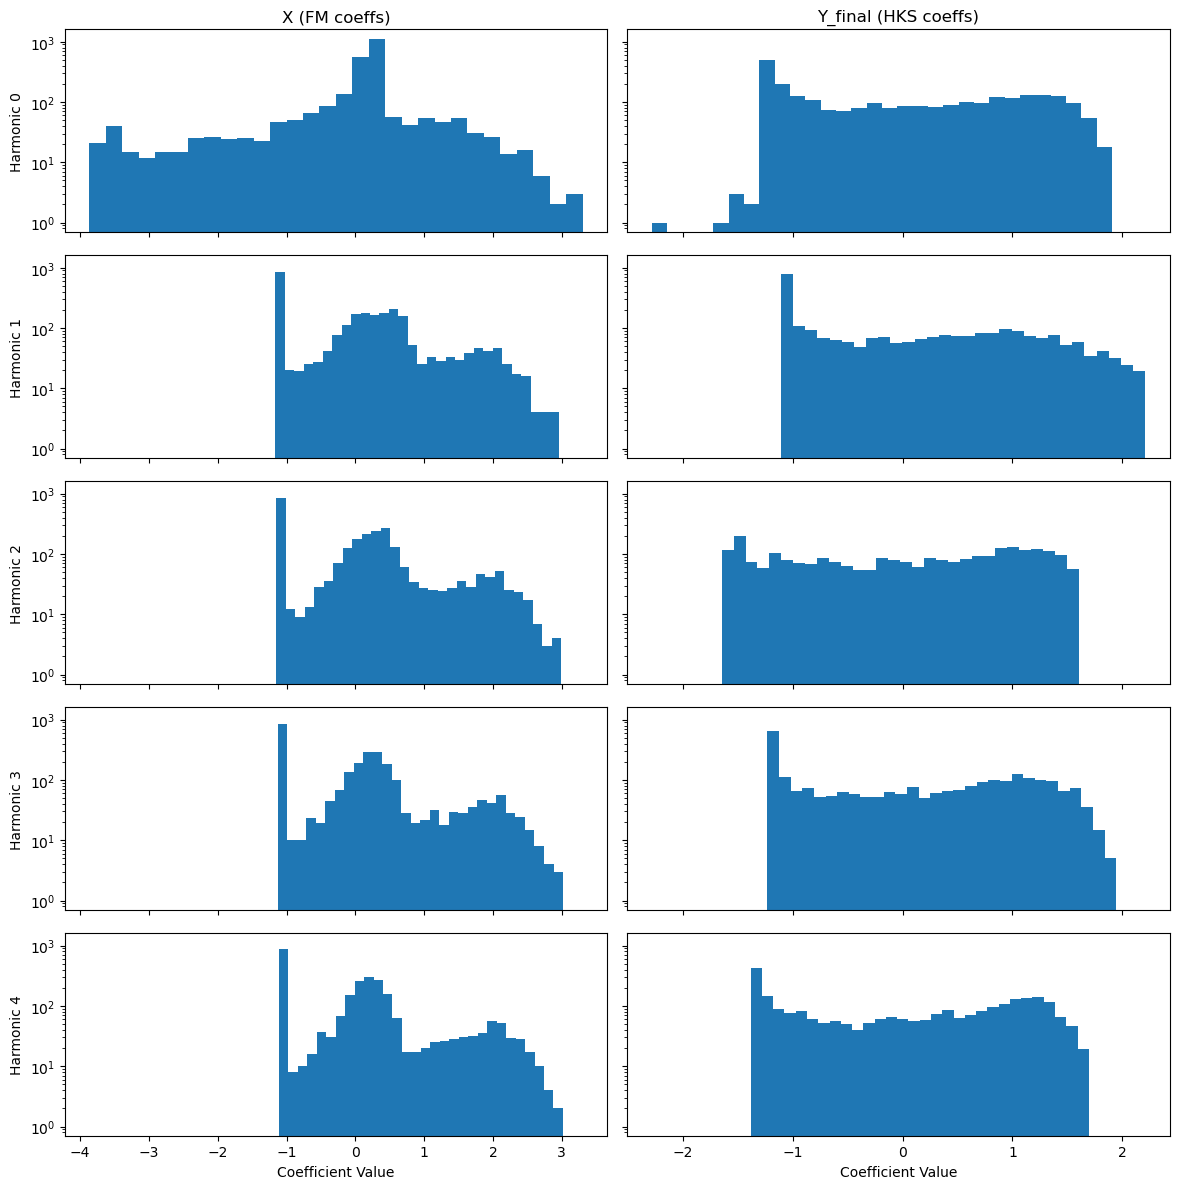

In [34]:
fig, axes = plt.subplots(5, 2, figsize=(12, 12), sharex='col', sharey=True)

for i in range(5):
    axes[i, 0].hist(X_inter[:, i], bins=30, alpha=1)
    axes[i, 0].set_ylabel(f'Harmonic {i}')
    if i == 0:
        axes[i, 0].set_title('X (FM coeffs)')
    
    axes[i, 1].hist(Y_final[:, i], bins=30, alpha=1)
    if i == 0:
        axes[i, 1].set_title('Y_final (HKS coeffs)')

axes[-1, 0].set_xlabel('Coefficient Value')
axes[-1, 1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.yscale('log')
plt.show()

Epoch [10/100], Train Loss: 0.3301, Test Loss: 0.3304
Epoch [20/100], Train Loss: 0.3088, Test Loss: 0.3154
Epoch [30/100], Train Loss: 0.3070, Test Loss: 0.3139
Epoch [40/100], Train Loss: 0.3086, Test Loss: 0.3133
Epoch [50/100], Train Loss: 0.3073, Test Loss: 0.3124
Epoch [60/100], Train Loss: 0.3079, Test Loss: 0.3132
Epoch [70/100], Train Loss: 0.3076, Test Loss: 0.3121
Epoch [80/100], Train Loss: 0.3080, Test Loss: 0.3128
Epoch [90/100], Train Loss: 0.3083, Test Loss: 0.3129
Epoch [100/100], Train Loss: 0.3080, Test Loss: 0.3133


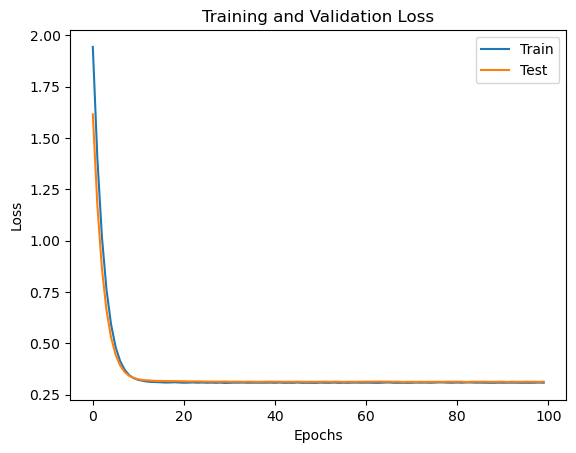

In [35]:
from torch.utils.data import DataLoader, TensorDataset

# Create data loaders
dataset = TensorDataset(torch.from_numpy(X_final).float(), torch.from_numpy(Y_final).float())
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize model
lmodel = LinearModel(input_dim=X_final.shape[1], output_dim=Y_final.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(lmodel.parameters(), lr=0.001)

train_losses, test_losses = train_with_validation(lmodel, train_loader, test_loader, criterion, optimizer, verbose=True, epochs=100)

plt.plot(train_losses)
plt.plot(test_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train', 'Test'])
plt.show()

In [98]:
vocab_names = ['endocrine', 'none', 'aldob', 'stem', 'exocrine']

weights = (pca.components_[:n_componets, :].T @ lmodel.linear.weight.data.numpy().T) 

plt.imshow(weights.T, aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(weights)), vmax=np.max(np.abs(weights)))
plt.colorbar()
plt.title('Learned Weights Heatmap')
for x in np.arange(0, coeffs_fm_reshaped.shape[1], coeffs_fm_rescaled.shape[1]):
    plt.axvline(x - 0.5, color='black', linewidth=1, alpha=1)
plt.xticks(ticks=np.arange(0+2.5, coeffs_fm_reshaped.shape[1], coeffs_fm_rescaled.shape[1]), labels=fm_names_of_choice, rotation=45)
plt.ylabel('crypt-ness')
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 10 is different from 35)

In [97]:
hks_linear_model = lmodel(torch.from_numpy(X_final).float()).detach().numpy()
higher_order_components = np.abs(coeffs_fm_filtered)[~sample_filter][:, 1:, :].sum(axis=(1, 2))

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

for i in range(5):
    index = i
    sc = axes[i].scatter(Y_final[:, index], hks_linear_model[:, index], c=np.log1p(higher_order_components), alpha=1, s=3, label='Predictions', cmap='viridis')
    plt.colorbar(sc, ax=axes[i])
    axes[i].plot([Y_final[:, index].min(), Y_final[:, index].max()], 
                 [Y_final[:, index].min(), Y_final[:, index].max()], 
                 'r--', linewidth=2, label='Ideal')
    axes[i].set_xlabel('True HKS vocab 7')
    axes[i].set_ylabel('Predicted HKS vocab 7')
    axes[i].set_title(f'Harmonic {i}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Linear Model: Predicted vs True HKS', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2667x35 and 10x5)

In [229]:
model = nn.Sequential(
    nn.Linear(X_final.shape[1], 32),       # A modest first layer
    nn.ReLU(),
    nn.Dropout(0.1),         # Dropout to fight overfitting (40% of neurons are ignored during training)

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(16, Y_final.shape[1])         # Output layer
)

# model = nn.Sequential(
#     nn.Linear(X_final.shape[1], 128),       # A modest first layer
#     nn.ReLU(),
#     nn.Dropout(0.2),         # Dropout to fight overfitting (40% of neurons are ignored during training)

#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Dropout(0.2),
#     nn.Linear(64, Y_final.shape[1])         # Output layer
# )

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

train_losses, test_losses = train_with_validation(model, train_loader, test_loader, criterion, optimizer, verbose=True, epochs=100)

Epoch [10/100], Train Loss: 0.2912, Test Loss: 0.2586
Epoch [20/100], Train Loss: 0.2760, Test Loss: 0.2445
Epoch [30/100], Train Loss: 0.2679, Test Loss: 0.2456
Epoch [40/100], Train Loss: 0.2624, Test Loss: 0.2509
Epoch [50/100], Train Loss: 0.2606, Test Loss: 0.2477
Epoch [60/100], Train Loss: 0.2563, Test Loss: 0.2439
Epoch [70/100], Train Loss: 0.2552, Test Loss: 0.2478
Epoch [80/100], Train Loss: 0.2555, Test Loss: 0.2395
Epoch [90/100], Train Loss: 0.2499, Test Loss: 0.2436
Epoch [100/100], Train Loss: 0.2495, Test Loss: 0.2466


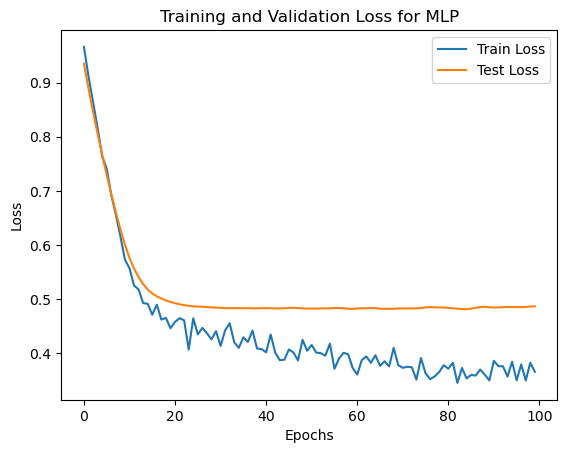

In [425]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for MLP')
plt.legend()
plt.show()

NameError: name 'higher_order_components' is not defined

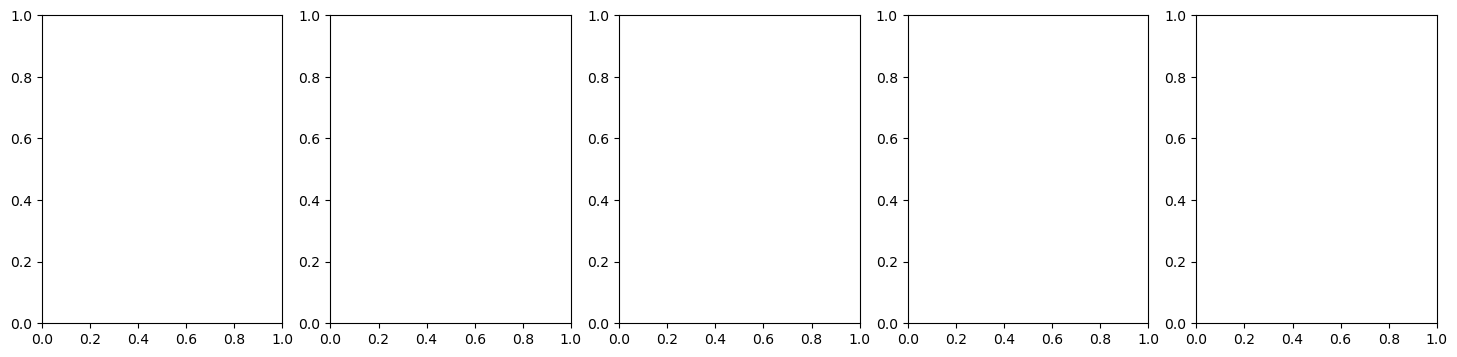

In [21]:
hks_mlp_model = mlp_model(torch.from_numpy(X_final).float()).detach().numpy()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i in range(5):
    index = i
    sc = axes[i].scatter(Y_final[:, index], hks_mlp_model[:, index], c=np.log1p(higher_order_components), alpha=0.5, s=3, label='Predictions', cmap='viridis')
    plt.colorbar(sc, ax=axes[i])
    axes[i].plot([Y_final[:, index].min(), Y_final[:, index].max()], 
                 [Y_final[:, index].min(), Y_final[:, index].max()], 
                 'r--', linewidth=2, label='Ideal')
    axes[i].set_xlabel('True HKS vocab 7')
    axes[i].set_ylabel('Predicted HKS vocab 7')
    axes[i].set_title(f'Harmonic {i}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_aspect('equal', adjustable='box')

plt.suptitle('Multi Layer Perceptron model: Predicted vs True HKS', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()